In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, chi2_contingency
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import os
from pathlib import Path
import datetime
import random
from matplotlib import style
# import f1 score and accuracy
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, matthews_corrcoef, balanced_accuracy_score
import gseapy as gp
import matplotlib.font_manager as fm

import pooch
import zipfile
from tqdm import tqdm
import hashlib

In [2]:
np.random.seed(42)
random.seed(42)

In [3]:
style.use('default')
style.use(
    '/lustre/scratch126/cellgen/lotfollahi/kl11/'
    'T_perturb/perturbgen/pp/mpl_style.mplstyle'
)

In [4]:
fm.fontManager.addfont('/nfs/team361/am74/Cytomeister/Evaluation_datasets/LPS/Private_emily/helvetica.ttf')

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica']
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams['axes.grid'] = False
sc.set_figure_params(dpi_save=600,fontsize=12)

In [5]:
adata = sc.read('/nfs/team361/am74/Cytomeister/configs/results/results/20260113-16:40_minference_adata_gENSG00000125538_ssrc_tmask.h5ad')

In [6]:
pred = adata.copy()
pred.X = pred.layers['pred_counts'].copy()

In [7]:
pred.obs['status'] = 'unperturbed'
adata.obs['status'] = 'perturbed'

In [8]:
adata.obs['status_time'] = 'perturbed_' + adata.obs['time_after_LPS'].astype(str)
pred.obs['status_time'] = 'unperturbed_' + pred.obs['time_after_LPS'].astype(str)

In [9]:
adata = adata.concatenate(pred)

/tmp/ipykernel_3406598/3760186430.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata.concatenate(pred)


In [10]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [11]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata.obs['cell_type_harmonized'] = adata.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata.obs['cell_type_harmonized'].cat.categories}
)

In [12]:
adata = adata[adata.obs['cell_type_harmonized'].isin(['CD14+ monocytes','Dendritic cells',
                                                     'CD16+ monocytes'])].copy()

In [13]:
adata_full = sc.read('/nfs/team361/am74/Cytomeister/Evaluation_datasets/LPS/full_lps.h5ad')

In [14]:
adata_full.var_names = adata_full.var['ensembl_id-0']

/software/cellgen/team361/am74/envs/moscot_env/lib/python3.10/site-packages/anndata/_core/anndata.py:835: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['ENSG00000177757', 'ENSG00000225880', 'ENSG00000230368', 'ENSG00000188976', 'ENSG00000187961']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


In [15]:
mapping = adata_full.var['gene_ids-0'].to_dict()
adata.var_names = adata.var_names.map(mapping)
adata = adata[:, adata.var_names.notnull()].copy()

In [16]:
IL1B = sc.read('/nfs/team361/am74/Cytomeister/notebooks/IL1B_KO_analysis/IL1B_myeloid.h5ad')

In [17]:
adata = adata[:, adata.var_names.isin(IL1B.var_names)]

In [18]:
IL1B = IL1B[:, IL1B.var_names.isin(adata.var_names)]


In [20]:
adata_6h = adata[adata.obs['time_after_LPS'] == '6h_LPS'].copy()
adata_10h = adata[adata.obs['time_after_LPS'] == '10h_LPS'].copy()

In [21]:
sc.tl.rank_genes_groups(
    IL1B,
    group="IL-1-beta",
    groupby="cytokine",
    reference='PBS',
    method="wilcoxon",
)
gt = sc.get.rank_genes_groups_df(IL1B, group="IL-1-beta")

/software/cellgen/team361/am74/envs/moscot_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


In [202]:
gt_de = gt.query("pvals_adj < 0.05 and abs(logfoldchanges) > 0.5")


In [203]:
gt_up   = gt_de.query("logfoldchanges > 0")
gt_down = gt_de.query("logfoldchanges < 0")

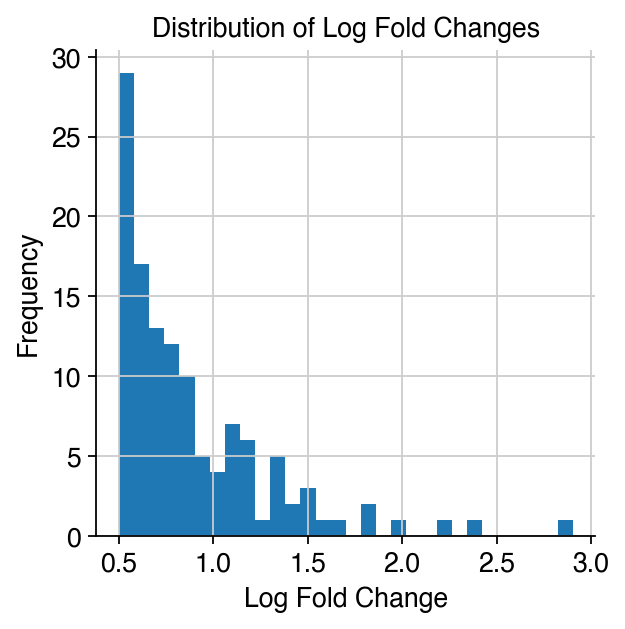

In [204]:
import matplotlib.pyplot as plt

# Plot histogram
plt.figure()
plt.hist(gt_up["logfoldchanges"], bins=30)

plt.xlabel("Log Fold Change")
plt.ylabel("Frequency")
plt.title("Distribution of Log Fold Changes")

plt.show()

In [205]:
gt_up_genes   = gt_up["names"].tolist()
gt_down_genes = gt_down["names"].tolist()


In [206]:
background = list(adata_6h.var_names)

In [207]:
import gseapy as gp

# download gene sets
gene_sets = gp.get_library(name="Reactome_Pathways_2024", organism="Human")

In [208]:
filtered_gene_sets = {
    k: v for k, v in gene_sets.items()
    if len(v) <= 500
}

In [209]:
import gseapy as gp

ora_up = gp.enrichr(
    gene_list=gt_up_genes,
    gene_sets=filtered_gene_sets,
    background=background,
    organism="Human",
    outdir=None,
    cutoff=0.05  # adj p-value cutoff
)

ora_down = gp.enrichr(
    gene_list=gt_down_genes,
    gene_sets=filtered_gene_sets,
    background=background,
    organism="Human",
    outdir=None,
    cutoff=0.05
)


In [210]:
def n_overlap(genes_str):
    return len(genes_str.split(";"))


In [211]:
up_df = ora_up.results
down_df = ora_down.results


In [212]:
up_df["n_overlap"] = up_df["Genes"].apply(n_overlap)
down_df["n_overlap"] = down_df["Genes"].apply(n_overlap)


In [213]:
up_df = up_df.query("`Adjusted P-value` < 0.05")
down_df = down_df.query("`Adjusted P-value` < 0.05")


In [214]:
gt = sc.get.rank_genes_groups_df(IL1B, group="IL-1-beta")

gt_sign = gt.set_index("names")["logfoldchanges"].apply(np.sign)
gt_weight = gt.set_index("names")["logfoldchanges"].abs()

In [215]:
sc.tl.rank_genes_groups(
    adata_6h,
    group="perturbed",
    groupby="status",
    reference='unperturbed',
    method="wilcoxon",
)

In [216]:
pred = sc.get.rank_genes_groups_df(adata_6h, group="perturbed")

pred_sign = pred.set_index("names")["logfoldchanges"].apply(np.sign)


In [217]:
def genes_from_df(df):
    return {
        row.Term: set(row.Genes.split(";"))
        for _, row in df.iterrows()
    }

P_up = genes_from_df(up_df)
P_down = genes_from_df(down_df)


In [218]:
def weighted_reversal_score(pathway_genes, pred_sign, gt_sign, gt_weight, min_genes=1):
    genes = [g for g in pathway_genes if (g in gt_sign.index) and (g in pred_sign.index)]
    if len(genes) < min_genes:
        return np.nan

    w = gt_weight.loc[genes].to_numpy()
    truth = gt_sign.loc[genes].to_numpy()
    pred = pred_sign.loc[genes].to_numpy()

    # reversed if pred == -truth (pred=0 counts as not reversed)
    rev = (pred == -truth)

    den = w.sum()
    return (w[rev].sum() / den) if den > 0 else np.nan

In [219]:
def mean_reversal_over_pathways(P, pred_sign, gt_sign, gt_weight, min_genes=1):
    scores = []
    for genes in P.values():
        s = weighted_reversal_score(genes, pred_sign, gt_sign, gt_weight, min_genes=min_genes)
        if not np.isnan(s):
            scores.append(s)
    return float(np.mean(scores)) if len(scores) else np.nan, len(scores)


In [220]:
T_obs_up, n_up = mean_reversal_over_pathways(P_up, pred_sign, gt_sign, gt_weight)
T_obs_down, n_down = mean_reversal_over_pathways(P_down, pred_sign, gt_sign, gt_weight)

In [221]:
def random_sign_null(P, gt_sign, gt_weight, pred_index, B=1000, seed=0, min_genes=5):
    rng = np.random.default_rng(seed)

    # sample only among genes that are actually "callable" in the observed pred_sign
    genes_eval = np.array([g for g in pred_index if g in gt_sign.index])

    null = np.empty(B, dtype=float)
    for b in range(B):
        rand_pred_sign = pd.Series(
            rng.choice([-1, 1], size=len(genes_eval)),
            index=genes_eval
        )
        T_b, _ = mean_reversal_over_pathways(P, rand_pred_sign, gt_sign, gt_weight, min_genes=min_genes)
        null[b] = T_b

    return null

In [222]:
def compute_reversal_for_adata(
    adata,
    P_up,
    gt_sign,
    gt_weight,
    B=5000,
    seed=0,
    min_genes=5,
    logfc_thresh=0,   
    pval_thresh=1
):
    # DE for this adata
    sc.tl.rank_genes_groups(
        adata,
        group="perturbed",
        groupby="status",
        reference="unperturbed",
        method="wilcoxon",
    )
    pred = sc.get.rank_genes_groups_df(adata, group="perturbed")
    pred = pred.loc[pred["logfoldchanges"].abs() >= logfc_thresh]
    pred = pred.loc[pred["pvals_adj"] < pval_thresh]

    # sign after filtering
    pred_sign = pred.set_index("names")["logfoldchanges"].apply(np.sign)

    # observed statistic
    T_obs, n_pathways = mean_reversal_over_pathways(
        P_up, pred_sign, gt_sign, gt_weight, min_genes=min_genes
    )

    null = random_sign_null(
        P_up, gt_sign, gt_weight,
        pred_index=pred_sign.index,
        B=B, seed=seed, min_genes=min_genes
    )
    return {
        "T_obs": T_obs,
        "n_pathways": n_pathways,
        "null": null,
        "null_mean": float(np.mean(null)),
        "null_sd": float(np.std(null, ddof=1)),
    }



In [223]:
res_6h = compute_reversal_for_adata(
    adata_6h,
    P_up,
    gt_sign,
    gt_weight,
    B=5000,
    seed=0,
)

res_10h = compute_reversal_for_adata(
    adata_10h,
    P_up,
    gt_sign,
    gt_weight,
    B=5000,
    seed=0,  # different seed is fine
)


In [224]:
P_down

{}

In [225]:
def empirical_p(null, T_obs):
    return (1 + np.sum(null >= T_obs)) / (len(null) + 1)

p_6h = empirical_p(res_6h["null"], res_6h["T_obs"])
p_10h = empirical_p(res_10h["null"], res_10h["T_obs"])

print("6h:", res_6h["T_obs"], "p_emp:", p_6h)
print("10h:", res_10h["T_obs"], "p_emp:", p_10h)

6h: 0.7539181709289551 p_emp: 0.003199360127974405
10h: 0.7794411778450012 p_emp: 0.004999000199960008


In [226]:
labels = ["Random sign null", "6h", "10h"]
means = [
    res_6h["null_mean"],   
    res_6h["T_obs"],
    res_10h["T_obs"],
]
errors = [
    res_6h["null_sd"],
    0,
    0,
]


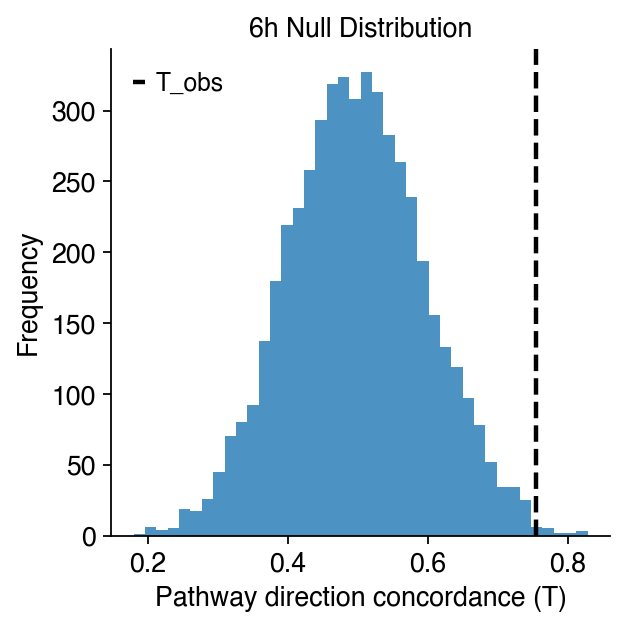

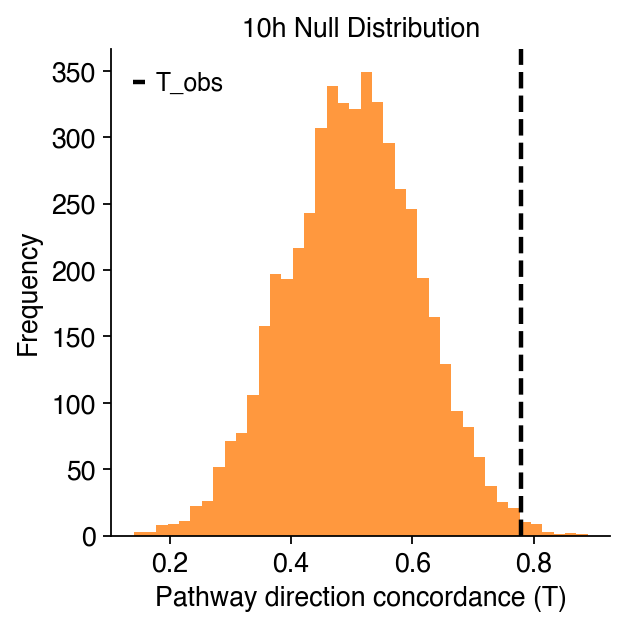

In [229]:
import matplotlib.pyplot as plt

# 6h histogram
plt.figure()
plt.hist(res_6h["null"], bins=40,
         color="#1f77b4", alpha=0.8)
plt.axvline(res_6h["T_obs"], linestyle="--",
            color="black", linewidth=2,
            label="T_obs")
plt.title("6h Null Distribution")
plt.xlabel("Pathway direction concordance (T)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(False)
plt.savefig('./6h_distribution.svg', dpi=600)
plt.show()


# 10h histogram
plt.figure()
plt.hist(res_10h["null"], bins=40,
         color="#ff7f0e", alpha=0.8)
plt.axvline(res_10h["T_obs"], linestyle="--",
            color="black", linewidth=2,
            label="T_obs")
plt.title("10h Null Distribution")
plt.xlabel("Pathway direction concordance (T)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(False)
plt.savefig('./10h_distribution.svg', dpi=600)
plt.show()

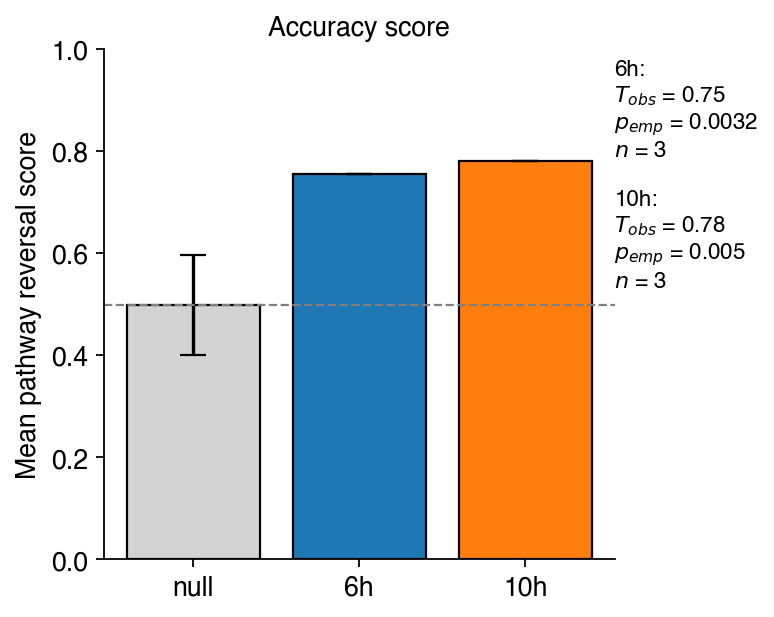

In [228]:
fig, ax = plt.subplots(figsize=(5, 4))

labels = ["null", "6h", "10h"]
means = [
    res_6h["null_mean"],
    res_6h["T_obs"],
    res_10h["T_obs"],
]
errors = [
    res_6h["null_sd"],  # keep SD-based error for null
    0,
    0,
]

ax.bar(
    labels,
    means,
    yerr=errors,
    capsize=6,
    color=["lightgray", "#1f77b4", "#ff7f0e"],
    edgecolor="black"
)

# reference line (unchanged)
ax.axhline(
    res_6h["null_mean"],
    linestyle="--",
    color="gray",
    linewidth=1
)

ax.set_ylabel("Mean pathway reversal score", fontsize=12)
ax.set_ylim(0, 1)
ax.set_title("Accuracy score")

# empirical p-values
p_6h = (1 + np.sum(res_6h["null"] >= res_6h["T_obs"])) / (len(res_6h["null"]) + 1)
p_10h = (1 + np.sum(res_10h["null"] >= res_10h["T_obs"])) / (len(res_10h["null"]) + 1)

# annotation block (same style as your example)
ax.text(
    0.999, 0.98,
    f"6h:\n"
    f"$T_{{obs}}$ = {res_6h['T_obs']:.2f}\n"
    f"$p_{{emp}}$ = {p_6h:.3g}\n"
    f"$n$ = {res_6h['n_pathways']}\n\n"
    f"10h:\n"
    f"$T_{{obs}}$ = {res_10h['T_obs']:.2f}\n"
    f"$p_{{emp}}$ = {p_10h:.3g}\n"
    f"$n$ = {res_10h['n_pathways']}",
    transform=ax.transAxes,
    va="top",
    fontsize=10
)

plt.tight_layout()
plt.grid(False)
plt.savefig('./accuracy_updated.svg',dpi=600)
plt.show()
